In [1]:
import pandas as pd

df= pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [2]:
from pathlib import Path

root = Path("/Users/gretawette/Documents/Thesis")

topics = pd.read_csv(
    root / "02_TopicModeling/outputs/03_new_topic_assignments.csv",
    usecols=["row_id", "source", "Manual Topic Label", "Manual Cluster Label"],
)

# Normalise source names to match the framing CSV
topics["source"] = topics["source"].replace({
    "RT":             "RT_de",
    "Tichys Einblick": "Tichys_Einblick",
})

df = df.merge(
    topics,
    on=["row_id", "source"],
    how="left",
)

print(f"Rows: {len(df)}")
print(f"Manual Topic Label   — filled: {df['Manual Topic Label'].notna().sum()}  |  missing: {df['Manual Topic Label'].isna().sum()}")
print(f"Manual Cluster Label — filled: {df['Manual Cluster Label'].notna().sum()}  |  missing: {df['Manual Cluster Label'].isna().sum()}")
print()
print(df[["source", "row_id", "category", "Manual Topic Label", "Manual Cluster Label"]].head(10).to_string(index=False))


Rows: 11975
Manual Topic Label   — filled: 11583  |  missing: 392
Manual Cluster Label — filled: 11583  |  missing: 392

     source  row_id                         category            Manual Topic Label          Manual Cluster Label
Antispiegel       1                          NEUTRAL            AfD Party Politics         German Party Politics
Antispiegel       4 DISINFORMATION/FALSCHDARSTELLUNG Ukrainian Military Operations            Russia-Ukraine War
Antispiegel       5             VERSAGEN/INKOMPETENZ         Corruption Journalism Media & Information Ecosystem
Antispiegel       5                       IRRELEVANT         Corruption Journalism Media & Information Ecosystem
Antispiegel       5 DISINFORMATION/FALSCHDARSTELLUNG         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media

## Filter data (exclude IRRELEVANT & Tagesschau)

In [3]:
df = df[df['category'] != 'IRRELEVANT']
df = df[df['source']   != 'Tagesschau']

print(f"Rows after filtering: {len(df)}")
print(f"Sources remaining: {sorted(df['source'].unique())}")


Rows after filtering: 7339
Sources remaining: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'Nius', 'RT_de', 'Tichys_Einblick']


## Topic Level Analysis

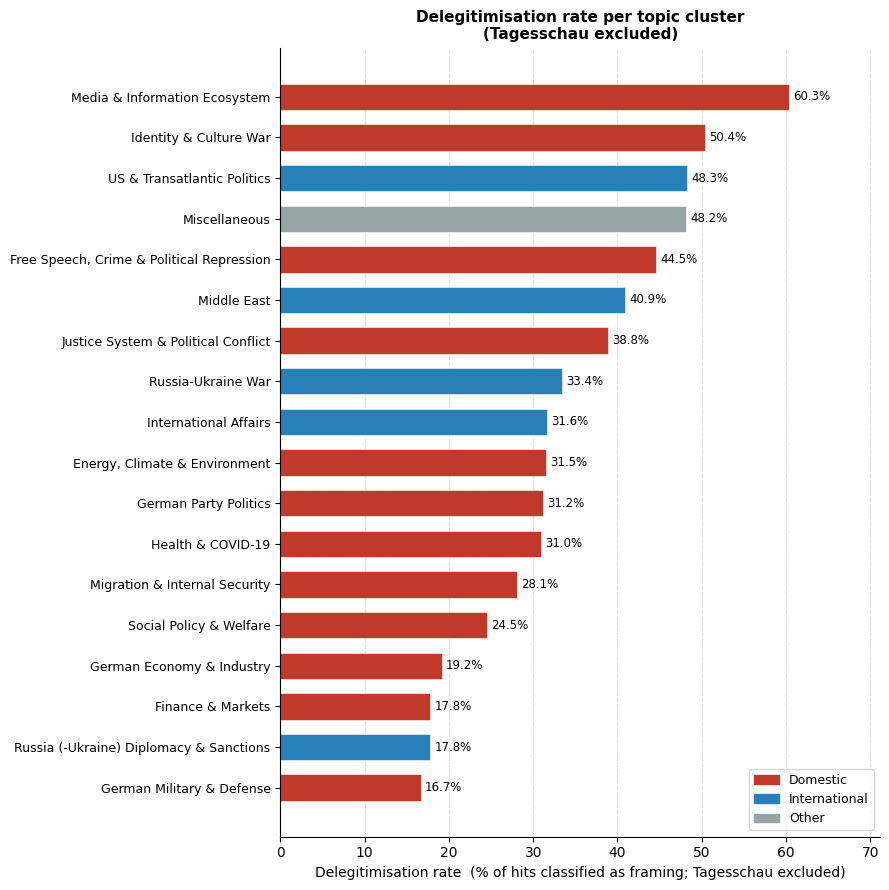

In [4]:
# ── Delegitimisation rate per topic cluster, coloured by geography ────────────
import matplotlib.pyplot as plt
DOMESTIC = {
    "Social Policy & Welfare",
    "Health & COVID-19",
    "Energy, Climate & Environment",
    "German Economy & Industry",
    "Migration & Internal Security",
    "German Party Politics",
    "Free Speech, Crime & Political Repression",
    "Media & Information Ecosystem",
    "Justice System & Political Conflict",
    "Identity & Culture War",
    "Finance & Markets",
    "German Military & Defense",
}
INTERNATIONAL = {
    "Middle East",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics",
    "Russia-Ukraine War",
    "International Affairs",
}


GEO_COLOR = {"Domestic": "#c0392b", "International": "#2980b9", "Other": "#95a5a6"}

def _geo(c):
    return "Domestic" if c in DOMESTIC else "International" if c in INTERNATIONAL else "Other"

df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

total_c   = df_known.groupby("Manual Cluster Label").size()
framing_c = df_known[df_known["category"] != "NEUTRAL"].groupby("Manual Cluster Label").size()

deleg = ((framing_c / total_c) * 100).dropna().sort_values(ascending=True)
colors = [GEO_COLOR[_geo(c)] for c in deleg.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(deleg) * 0.5)))
bars = ax.barh(deleg.index, deleg.values, color=colors, edgecolor="white", linewidth=0.4, height=0.65)

for bar, val in zip(bars, deleg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8.5)

ax.set_xlabel("Delegitimisation rate  (% of hits classified as framing; Tagesschau excluded)", fontsize=10)
ax.set_xlim(0, deleg.max() * 1.18)
ax.set_title("Delegitimisation rate per topic cluster\n(Tagesschau excluded)", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in GEO_COLOR.items()],
          loc="lower right", fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


In [5]:
# ── Average delegitimisation rate: domestic vs international per outlet ───────
# Reuses df_known, _geo(), from cell above

df_known["geo"] = df_known["Manual Cluster Label"].map(_geo)

results = []
for outlet, grp in df_known[df_known["source"] != "Tagesschau"].groupby("source"):
    for geo in ("Domestic", "International"):
        sub     = grp[grp["geo"] == geo]
        total   = len(sub)
        if total == 0:
            continue
        framing = (sub["category"] != "NEUTRAL").sum()
        results.append({
            "Outlet": outlet,
            "Geography": geo,
            "Delegitimisation rate": framing / total * 100,
            "n": total,
        })

summary = (
    pd.DataFrame(results)
    .pivot(index="Outlet", columns="Geography", values="Delegitimisation rate")
    .round(1)
)
summary.columns.name = None
summary["Δ (Dom − Intl)"] = (summary["Domestic"] - summary["International"]).round(1)
summary = summary.sort_values("Domestic", ascending=False)
print(summary.to_string())


                   Domestic  International  Δ (Dom − Intl)
Outlet                                                    
Antispiegel            72.4           48.5            23.9
Tichys_Einblick        48.6           52.8            -4.2
Compact                35.9           38.7            -2.8
Nius                   33.5           58.5           -25.0
Deutschlandkurier      32.6           19.6            13.0
RT_de                  22.4           13.8             8.6


In [ ]:
# ── Heatmap: delegitimisation rate per topic cluster × outlet ────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

MIN_N = 5   # cells with fewer hits shown as grey/—

# ── Build pivot tables ────────────────────────────────────────────────────────
df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

# Total hits per (cluster, outlet)
total_g = (
    df_known
    .groupby(["Manual Cluster Label", "source"])
    .size()
    .unstack(fill_value=0)
    .astype(float)
)

# Non-neutral hits per (cluster, outlet)
framed_g = (
    df_known[df_known["category"] != "NEUTRAL"]
    .groupby(["Manual Cluster Label", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex_like(total_g)
    .fillna(0)
)

# Raw delegitimisation rate (%)
rate_raw = (framed_g / total_g.replace(0, np.nan)) * 100

# ── Geo-sort: Domestic → International → Other ────────────────────────────────
def _geo_rank(cluster):
    if cluster in DOMESTIC:      return 0
    if cluster in INTERNATIONAL: return 1
    return 2

sorted_clusters = sorted(rate_raw.index.tolist(), key=_geo_rank)
rate_vis  = rate_raw.reindex(sorted_clusters)
total_vis = total_g.reindex(sorted_clusters)

# Mask cells below MIN_N (grey them out)
rate_plot = rate_vis.where(total_vis >= MIN_N)

# ── Geo-bracket helper ────────────────────────────────────────────────────────
def _add_geo_brackets(ax, clusters_ordered):
    last_dom   = None
    first_intl = None
    for i, c in enumerate(clusters_ordered):
        if c in DOMESTIC:
            last_dom = i
        elif c in INTERNATIONAL and first_intl is None:
            first_intl = i
    if last_dom is None or first_intl is None:
        return
    sep_y = first_intl   # seaborn row-i occupies y=[i, i+1]; boundary is at y=first_intl
    ax.plot([-0.55, 1.0], [sep_y, sep_y], color="#555555", linewidth=1.2,
            linestyle="--", zorder=4, transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y - 0.35, "Domestic",
            ha="right", va="bottom", fontsize=8, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y + 0.35, "International",
            ha="right", va="top", fontsize=8, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)

# ── Color scale: diverging blue→red centered on grand mean ────────────────────
all_outlets  = rate_plot.columns.tolist()
macro_mean   = float(np.nanmean(rate_plot.values))
spread       = max(float(np.nanmax(np.abs(rate_plot.values - macro_mean))), 1e-6)
vmin, vmax   = macro_mean - spread, macro_mean + spread

fig, ax = plt.subplots(figsize=(max(9, 1.1 * len(all_outlets)),
                                max(7, 0.52 * len(sorted_clusters))))

sns.heatmap(rate_plot, ax=ax, annot=False,
            cmap="RdBu_r", center=macro_mean, vmin=vmin, vmax=vmax,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": f"Delegitimisation rate %  (macro-μ = {macro_mean:.1f}%)"})

# ── Cell annotations ──────────────────────────────────────────────────────────
for ri, cluster in enumerate(sorted_clusters):
    for ci, outlet in enumerate(all_outlets):
        val = rate_plot.at[cluster, outlet]
        n   = total_vis.at[cluster, outlet]
        if np.isnan(val):
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            ax.text(ci + 0.5, ri + 0.5, "—",
                    ha="center", va="center", fontsize=8, color="#aaaaaa", zorder=3)
        else:
            ax.text(ci + 0.5, ri + 0.5, f"{val:.0f}%\n(n={int(n)})",
                    ha="center", va="center", fontsize=7.5, color="black", zorder=3)

ax.set_title(
    "Delegitimisation rate per topic cluster × outlet\n"
    f"(cells with fewer than {MIN_N} hits shown as grey; Tagesschau excluded)",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Outlet", fontsize=9)
ax.set_ylabel("Topic cluster", fontsize=9)
_add_geo_brackets(ax, sorted_clusters)
plt.tight_layout()
plt.show()


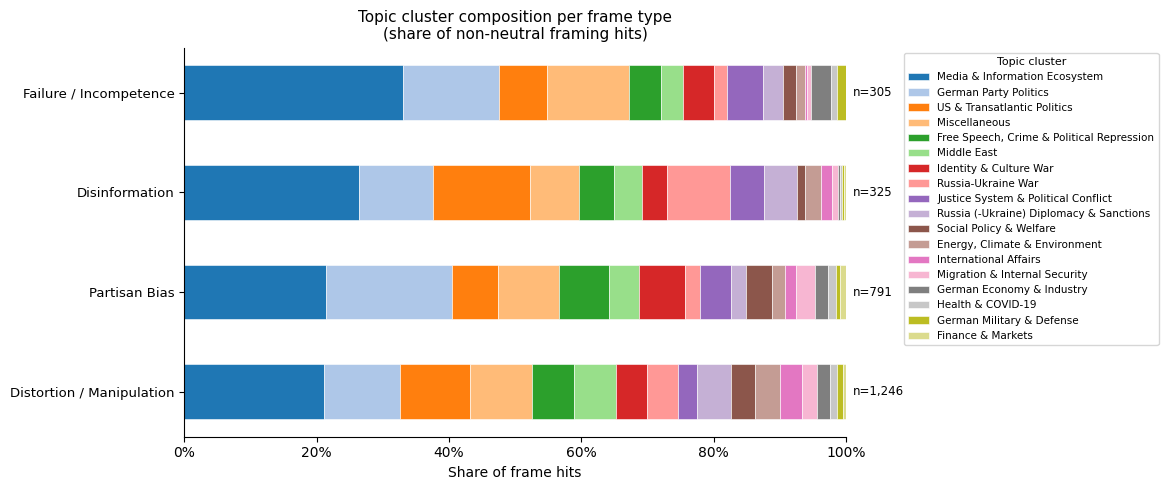

In [7]:
CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
}
FRAME_ORDER = list(CATEGORY_EN.values())

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

# Counts: frame × cluster (raw hits)
pivot = (
    df_framed.groupby(["frame_en", "Manual Cluster Label"])
    .size()
    .unstack(fill_value=0)
    .reindex(FRAME_ORDER)
)

# Normalise each row → % share of that frame's hits
props = pivot.div(pivot.sum(axis=1), axis=0) * 100
totals = pivot.sum(axis=1)

# Sort clusters by total hits descending so legend order is meaningful
cluster_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
props = props[cluster_order]

cmap = plt.get_cmap("tab20")
cluster_colors = {c: cmap(i % 20) for i, c in enumerate(cluster_order)}

fig, ax = plt.subplots(figsize=(12, 5))

lefts = np.zeros(len(props))
for cluster in cluster_order:
    vals = props[cluster].values
    ax.barh(props.index, vals, left=lefts,
            color=cluster_colors[cluster], label=cluster,
            edgecolor="white", linewidth=0.4, height=0.55)
    lefts += vals

# Total hit count at bar end
for i, (frame, total) in enumerate(totals.items()):
    ax.text(101, i, f"n={total:,}", va="center", ha="left", fontsize=8.5)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of frame hits")
ax.set_title(
    "Topic cluster composition per frame type\n"
    "(share of non-neutral framing hits)",
    fontsize=11
)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9.5)
ax.legend(
    loc="upper left", bbox_to_anchor=(1.08, 1),
    fontsize=7.5, frameon=True, title="Topic cluster",
    title_fontsize=8
)

plt.tight_layout()
plt.show()


In [8]:
import math

In [9]:
CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan / Positional Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation / Falsehood",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
}

df["category_en"] = df["category"].map(CATEGORY_EN)

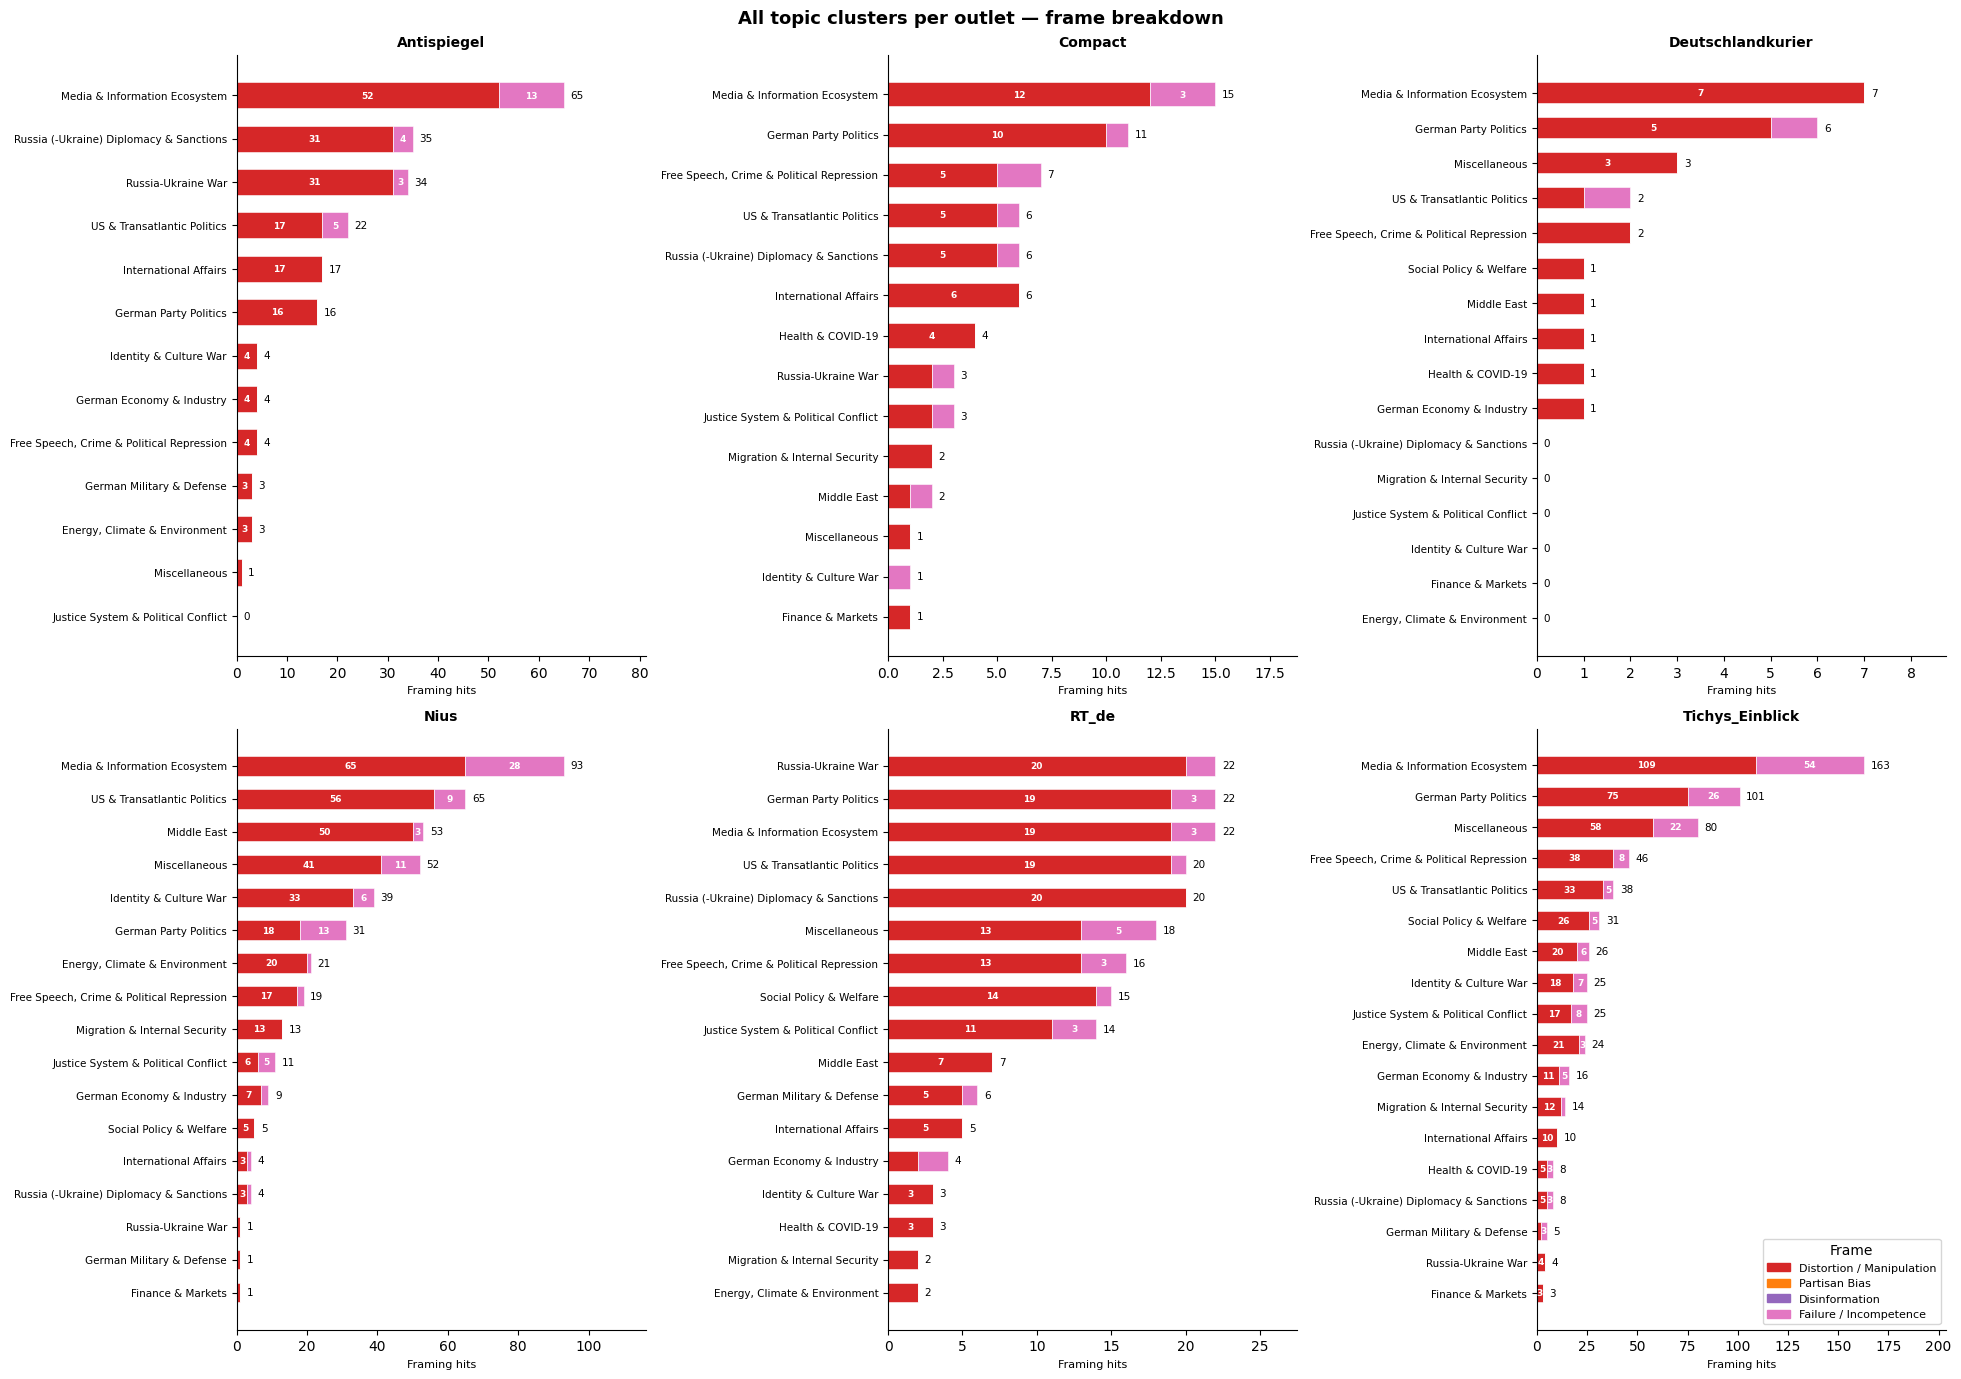

In [10]:


FRAME_COLORS = {
    "Distortion / Manipulation": "#d62728",
    "Partisan Bias":             "#ff7f0e",
    "Disinformation":            "#9467bd",
    "Failure / Incompetence":    "#e377c2",
}

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

outlets = sorted(df_framed["source"].unique())
ncols   = 3
nrows   = math.ceil(len(outlets) / ncols)

n_clusters = df_framed['Manual Cluster Label'].nunique()
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 6.5, nrows * max(4, n_clusters * 0.38)),
                         constrained_layout=True)
axes = axes.flatten()

for ax, outlet in zip(axes, outlets):
    sub = df_framed[df_framed["source"] == outlet]

    pivot = (
        sub.groupby(["Manual Cluster Label", "frame_en"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=FRAME_ORDER, fill_value=0)
    )
    # All clusters, sorted ascending by total hits (largest at top in barh)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    lefts = np.zeros(len(pivot))
    for frame in FRAME_ORDER:
        if frame not in pivot.columns:
            continue
        vals = pivot[frame].values
        ax.barh(pivot.index, vals, left=lefts,
                color=FRAME_COLORS[frame], label=frame,
                edgecolor="white", linewidth=0.4, height=0.6)
        for i, (v, l) in enumerate(zip(vals, lefts)):
            if v >= 3:
                ax.text(l + v / 2, i, str(v), ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
        lefts += vals

    # Total label
    for i, total in enumerate(pivot.sum(axis=1)):
        ax.text(total + pivot.sum(axis=1).max() * 0.02, i, str(total),
                va="center", fontsize=7.5)

    ax.set_xlim(0, pivot.sum(axis=1).max() * 1.25)
    ax.set_title(outlet, fontweight="bold", fontsize=10)
    ax.set_xlabel("Framing hits", fontsize=8)
    ax.tick_params(axis="y", labelsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend on last used axis
handles = [plt.Rectangle((0,0),1,1, color=FRAME_COLORS[f], label=f) for f in FRAME_ORDER]
axes[len(outlets)-1].legend(handles=handles, loc="lower right",
                             fontsize=8, frameon=True, title="Frame")

for ax in axes[len(outlets):]:
    ax.set_visible(False)

fig.suptitle(
    "All topic clusters per outlet — frame breakdown",
    fontsize=13, fontweight="bold"
)
plt.show()


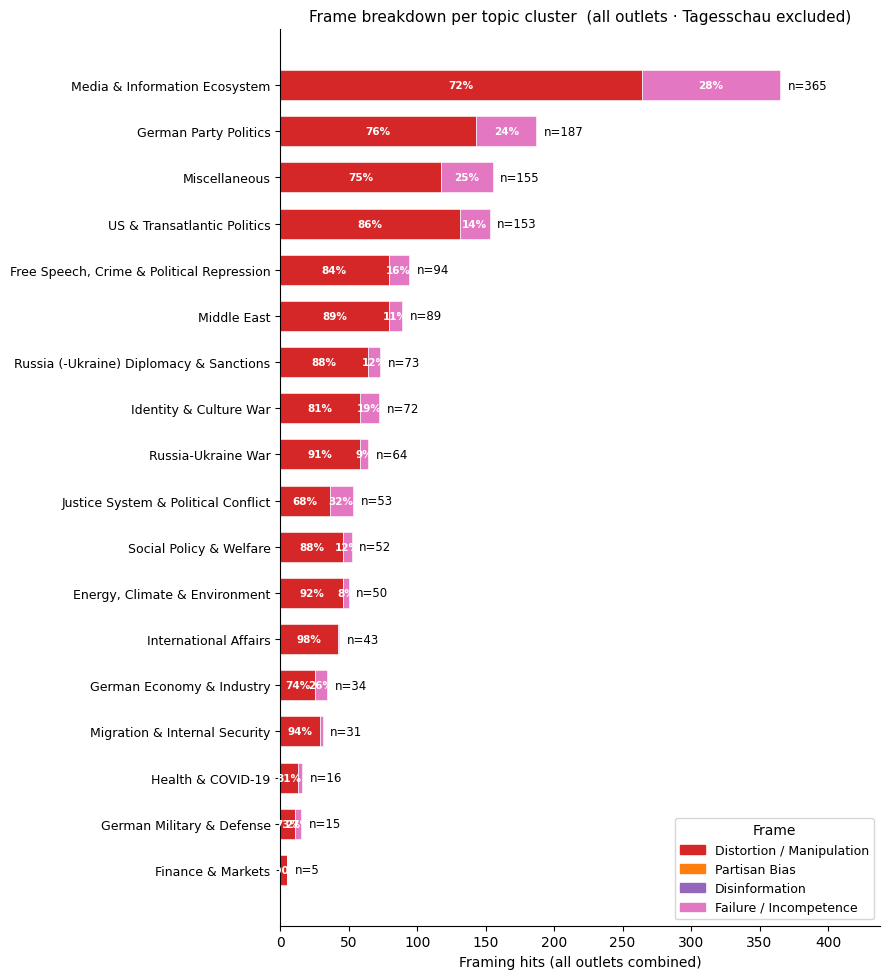

In [11]:
# ── All topic clusters — frame breakdown, bars = raw counts, labels = % ──────
pivot_all = (
    df_framed.groupby(["Manual Cluster Label", "frame_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER, fill_value=0)
)

# Sort ascending so the most-framed cluster ends up at top
pivot_all  = pivot_all.loc[pivot_all.sum(axis=1).sort_values(ascending=True).index]
totals_all = pivot_all.sum(axis=1)
pct_all    = pivot_all.div(totals_all, axis=0) * 100   # for label only

fig, ax = plt.subplots(figsize=(9, max(5, len(pivot_all) * 0.55)))

lefts = np.zeros(len(pivot_all))
for frame in FRAME_ORDER:
    if frame not in pivot_all.columns:
        continue
    vals     = pivot_all[frame].values
    pct_vals = pct_all[frame].values
    ax.barh(pivot_all.index, vals, left=lefts,
            color=FRAME_COLORS[frame], label=frame,
            edgecolor="white", linewidth=0.4, height=0.65)
    for i, (v, p, l) in enumerate(zip(vals, pct_vals, lefts)):
        if v >= 4:
            ax.text(l + v / 2, i, f"{p:.0f}%",
                    ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold")
    lefts += vals

# Raw n= at bar end
for i, (cluster, total) in enumerate(totals_all.items()):
    ax.text(total + totals_all.max() * 0.015, i, f"n={int(total)}",
            va="center", fontsize=8.5)

ax.set_xlim(0, totals_all.max() * 1.2)
ax.set_xlabel("Framing hits (all outlets combined)", fontsize=10)
ax.set_title("Frame breakdown per topic cluster  (all outlets · Tagesschau excluded)",
             fontsize=11)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=FRAME_COLORS[f]) for f in FRAME_ORDER]
ax.legend(handles, FRAME_ORDER, loc="lower right", fontsize=9, frameon=True, title="Frame")

plt.tight_layout()
plt.show()


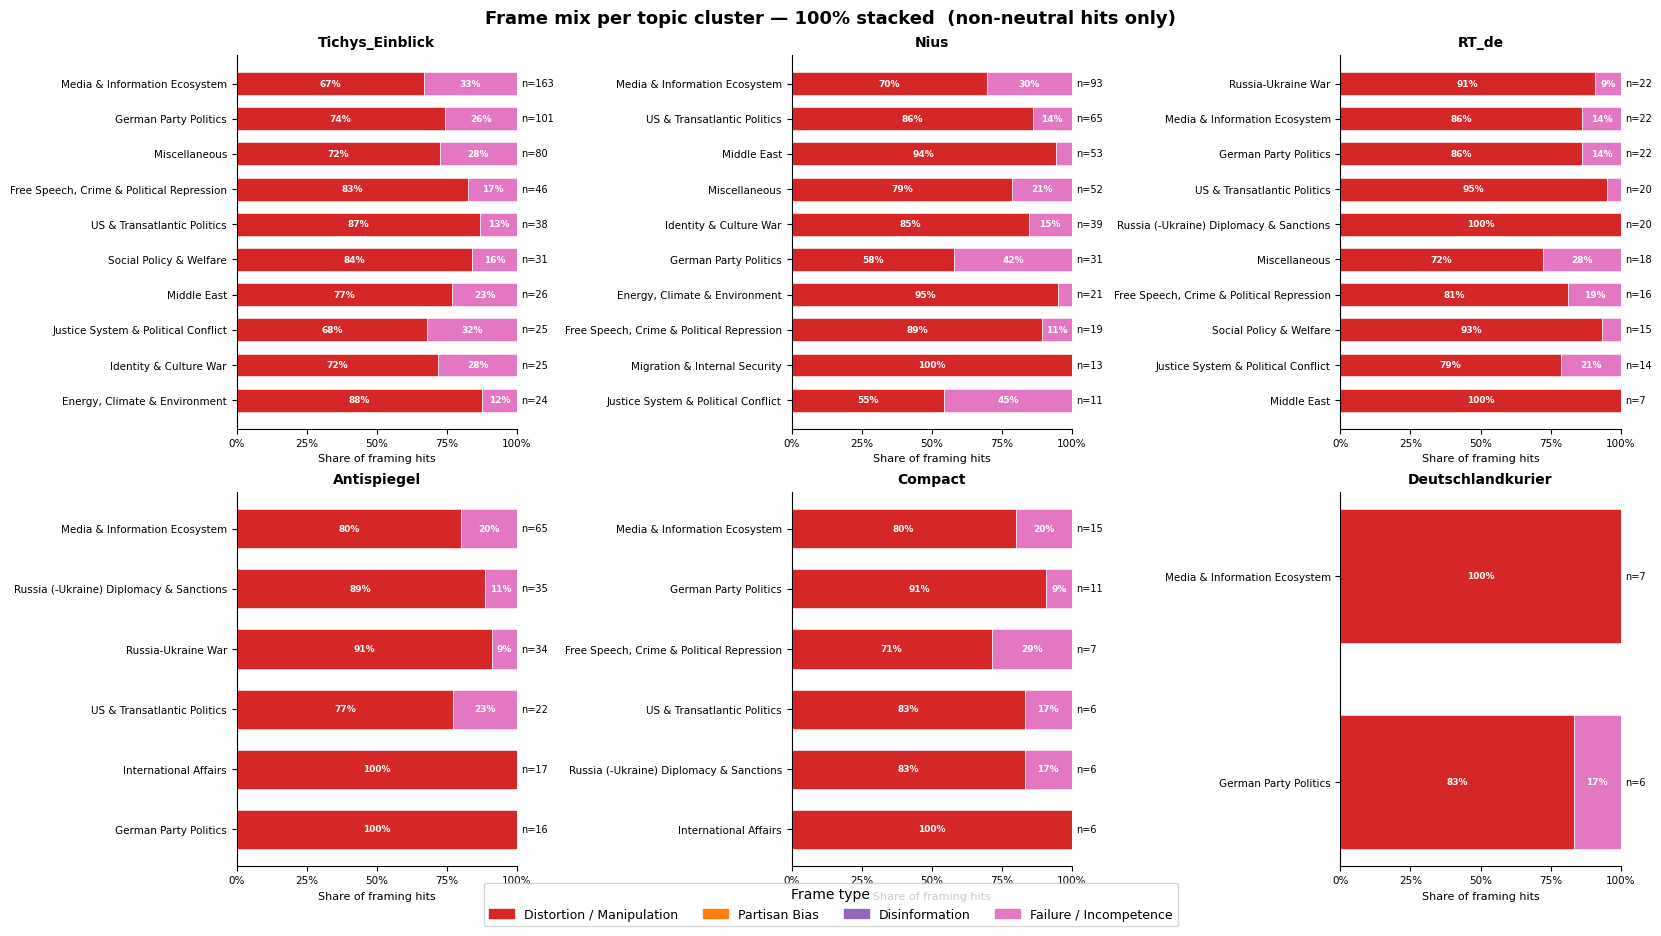

In [12]:
# ── Small multiples: 100% stacked bar — frame mix per topic cluster per outlet
# Each row = one topic cluster, each bar = 100%, segments = frame share.
# Normalised PER ROW so you can compare frame composition across outlets.

TOP_N_CLUSTERS = 10   # clusters shown per outlet (by total non-neutral hit count)
MIN_N          = 5    # hide rows with fewer than this many hits

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

outlets = (
    df_framed.groupby("source").size()
    .sort_values(ascending=False)
    .index.tolist()
)
ncols   = 3
nrows   = math.ceil(len(outlets) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 5.5, nrows * 4.5),
    constrained_layout=True,
)
axes = axes.flatten()

for ax, outlet in zip(axes, outlets):
    sub = df_framed[df_framed["source"] == outlet]

    # Raw counts: cluster × frame
    raw = (
        sub.groupby(["Manual Cluster Label", "frame_en"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=FRAME_ORDER, fill_value=0)
    )

    # Keep top N clusters by total hits; drop rows below MIN_N
    raw = raw[raw.sum(axis=1) >= MIN_N]
    if raw.empty:
        ax.set_visible(False)
        continue
    top_clusters = raw.sum(axis=1).nlargest(TOP_N_CLUSTERS).index
    raw = raw.loc[top_clusters]

    # Normalise each row to 100%
    totals = raw.sum(axis=1)
    pct    = raw.div(totals, axis=0) * 100

    # Sort by total hit count ascending so most-framed cluster is at the top
    pct = pct.loc[totals.sort_values(ascending=True).index]
    totals = totals.reindex(pct.index)

    lefts = np.zeros(len(pct))
    for frame in FRAME_ORDER:
        vals = pct[frame].values
        ax.barh(range(len(pct)), vals, left=lefts,
                color=FRAME_COLORS[frame], label=frame,
                edgecolor="white", linewidth=0.4, height=0.65)
        for i, (v, l) in enumerate(zip(vals, lefts)):
            if v >= 8:
                ax.text(l + v / 2, i, f"{v:.0f}%",
                        ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
        lefts += vals

    # n= annotation at bar end
    for i, (cluster, n) in enumerate(totals.items()):
        ax.text(101.5, i, f"n={n}", va="center", fontsize=7)

    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_yticks(range(len(pct)))
    ax.set_yticklabels(pct.index, fontsize=7.5)
    ax.set_title(outlet, fontweight="bold", fontsize=10)
    ax.set_xlabel("Share of framing hits", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=7.5)

# Shared legend
handles = [plt.Rectangle((0,0),1,1, color=FRAME_COLORS[f], label=f)
           for f in FRAME_ORDER]
fig.legend(handles=handles, loc="lower center",
           ncol=len(FRAME_ORDER), fontsize=9,
           frameon=True, title="Frame type",
           bbox_to_anchor=(0.5, -0.03))

for ax in axes[len(outlets):]:
    ax.set_visible(False)

fig.suptitle(
    "Frame mix per topic cluster — 100% stacked  (non-neutral hits only)",
    fontsize=13, fontweight="bold"
)
plt.show()


## Hit Analysis



In [13]:
# Split combined hit_text entries like "ARD | ZDF | Spiegel" into one row each
df = (
    df.assign(hit_text=df["hit_text"].str.split(r"\s*\|\s*"))
    .explode("hit_text")
    .assign(hit_text=lambda d: d["hit_text"].str.strip())
)

print(f"Rows after splitting combined hits: {len(df)}")
print(df["hit_text"].value_counts().head(20))

Rows after splitting combined hits: 9616
hit_text
ZDF                    1141
ARD                     966
Spiegel                 932
Markus Lanz             444
Reuters                 437
Tagesschau              413
Politico                385
FAZ                     335
ÖRR                     321
taz                     268
Handelsblatt            241
NDR                     234
Berliner Zeitung        226
Bild                    222
Tagesspiegel            217
Stern                   198
WDR                     187
Süddeutsche Zeitung     186
Deutschlandfunk         175
Jan Böhmermann          172
Name: count, dtype: int64


In [14]:
# ── Diagnostics: Deutschlandkurier hit counts at each pipeline stage ──────────
OUTLET = "Deutschlandkurier"
SKIP   = {"NEUTRAL", "IRRELEVANT"}

sub = df[df["source"] == OUTLET].copy()

print("=== After load + merge + hit_text split ===")
print(f"Total rows (all categories):            {len(sub)}")

non_neutral = sub[~sub["category"].isin(SKIP)]
print(f"Non-neutral/irrelevant hits (raw rows): {len(non_neutral)}")

no_topic = non_neutral[non_neutral["Manual Cluster Label"].isna()]
has_topic = non_neutral[non_neutral["Manual Cluster Label"].notna()]
print(f"  of which — no topic assignment (NaN): {len(no_topic)}")
print(f"  of which — has topic assignment:      {len(has_topic)}")
print()

print("=== Article-level (dedup by row_id) ===")
# Dedup before split: one article can expand to multiple hit rows after explode
nn_dedup = non_neutral.drop_duplicates(subset=["row_id"])
print(f"Unique articles (row_id) non-neutral:   {len(nn_dedup)}")
nn_topic_dedup = has_topic.drop_duplicates(subset=["row_id"])
print(f"Unique articles with topic assignment:  {len(nn_topic_dedup)}")
print()

print("=== Source of difference ===")
hit_diff = len(non_neutral) - len(has_topic)
art_diff = len(nn_dedup) - len(nn_topic_dedup)
print(f"Hit-level  gap (non-neutral − has_topic):             {hit_diff}")
print(f"Article-level gap (unique non-neutral − unique+topic): {art_diff}")
print()

# Check whether hit_text split inflated counts
orig_ids = sub["row_id"].value_counts()
multi = orig_ids[orig_ids > 1]
print(f"row_ids with >1 hit row after split: {len(multi)}")
print(f"Extra rows from splitting:           {multi.sum() - len(multi)}")
print()

# Category breakdown of the NaN-topic non-neutral rows
print("Category breakdown of no-topic non-neutral rows:")
print(no_topic["category"].value_counts().to_string())
print()
print("Sample no-topic rows:")
print(no_topic[["row_id", "category", "hit_text", "Manual Cluster Label"]].head(10).to_string(index=False))


=== After load + merge + hit_text split ===
Total rows (all categories):            497
Non-neutral/irrelevant hits (raw rows): 202
  of which — no topic assignment (NaN): 25
  of which — has topic assignment:      177

=== Article-level (dedup by row_id) ===
Unique articles (row_id) non-neutral:   92
Unique articles with topic assignment:  85

=== Source of difference ===
Hit-level  gap (non-neutral − has_topic):             25
Article-level gap (unique non-neutral − unique+topic): 7

row_ids with >1 hit row after split: 113
Extra rows from splitting:           206

Category breakdown of no-topic non-neutral rows:
category
POSITIONS-/PARTEILICHKEITS-BIAS     16
VERZERRUNG/MANIPULATION              6
VERSAGEN/INKOMPETENZ                 2
DISINFORMATION/FALSCHDARSTELLUNG     1

Sample no-topic rows:
 row_id                        category            hit_text Manual Cluster Label
  13033 POSITIONS-/PARTEILICHKEITS-BIAS Süddeutsche Zeitung                  NaN
  13033 POSITIONS-/PARTEILI

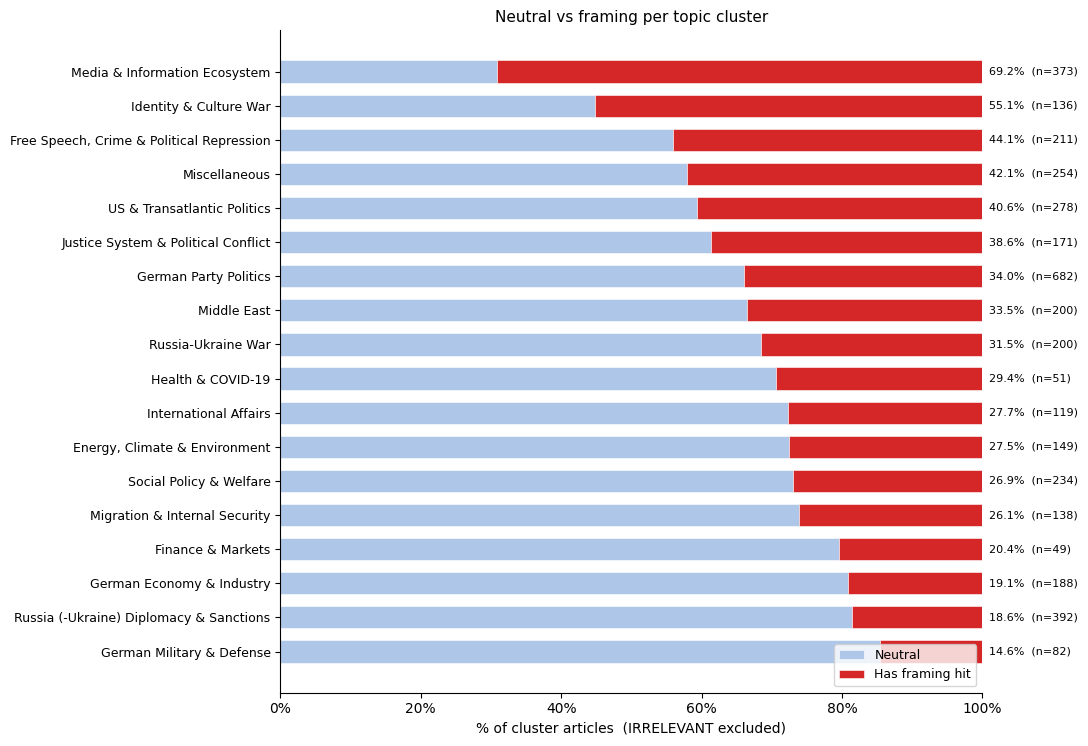

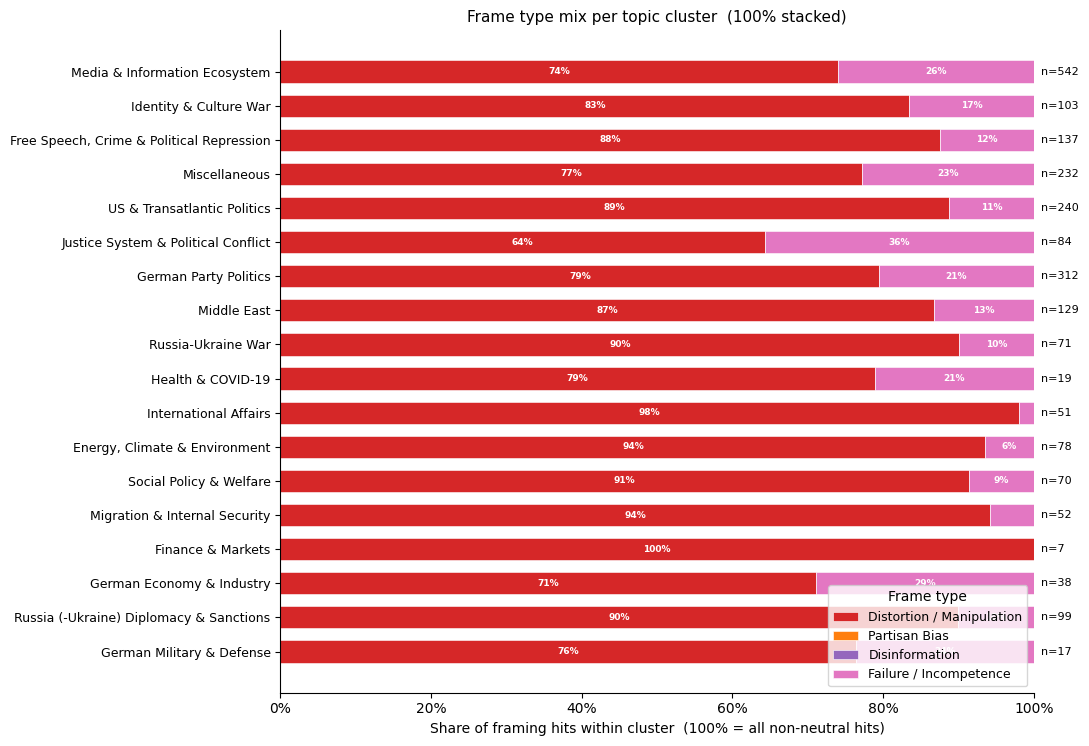

In [15]:
# ── Two companion charts to the outlet-coloured framing rate bar chart ────────
#
# Chart A: per cluster — % neutral vs % with framing hits  (IRRELEVANT excluded)
# Chart B: per cluster — framing hits broken down by frame type
#          bar length = same total non-neutral rate; colour = frame type

SKIP_IRRELEVANT = {"IRRELEVANT"}

# ── Shared base: articles per cluster, IRRELEVANT excluded ────────────────────
base = df[~df["category"].isin(SKIP_IRRELEVANT)].dropna(subset=["Manual Cluster Label"])

# Article-level flag: has ≥1 non-neutral hit?
art_flags = (
    base.groupby(["row_id", "source", "Manual Cluster Label"])["category"]
    .apply(lambda cats: any(c not in {"NEUTRAL", "IRRELEVANT"} for c in cats))
    .reset_index(name="has_frame")
)
total_per_cluster = art_flags.groupby("Manual Cluster Label")["has_frame"].count()
framed_count      = art_flags[art_flags["has_frame"]].groupby("Manual Cluster Label").size()
framed_pct        = (framed_count / total_per_cluster * 100).fillna(0)
neutral_pct       = 100 - framed_pct

# Sort clusters: highest framing rate at top
order = framed_pct.sort_values(ascending=True).index

# ── Chart A ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.42)))

ax.barh(order, neutral_pct[order],               color="#aec7e8", label="Neutral",  height=0.65, edgecolor="white", lw=0.4)
ax.barh(order, framed_pct[order],  left=neutral_pct[order],
        color="#d62728", label="Has framing hit", height=0.65, edgecolor="white", lw=0.4)

for i, cluster in enumerate(order):
    fp = framed_pct[cluster]
    n  = int(total_per_cluster[cluster])
    ax.text(101, i, f"{fp:.1f}%  (n={n})", va="center", ha="left", fontsize=8)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("% of cluster articles  (IRRELEVANT excluded)")
ax.set_title("Neutral vs framing per topic cluster", fontsize=11)
ax.legend(loc="lower right", fontsize=9, frameon=True)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Chart B: frame-type breakdown — 100% stacked per cluster ─────────────────
# Normalised to 100% of framing hits within each cluster
df_framing = base[base["category"].isin(CATEGORY_EN)].copy()
df_framing["frame_en"] = df_framing["category"].map(CATEGORY_EN)

hit_counts = (
    df_framing.groupby(["Manual Cluster Label", "frame_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER, fill_value=0)
)
# Normalise each row to 100% of that cluster's framing hits
hit_totals = hit_counts.sum(axis=1)
frame_pct  = hit_counts.div(hit_totals, axis=0).fillna(0) * 100
frame_pct  = frame_pct.loc[order]   # same cluster order as Chart A
hit_totals = hit_totals.reindex(order)

fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.42)))

lefts = np.zeros(len(frame_pct))
for frame in FRAME_ORDER:
    vals = frame_pct[frame].values
    ax.barh(frame_pct.index, vals, left=lefts,
            color=FRAME_COLORS[frame], label=frame,
            height=0.65, edgecolor="white", lw=0.4)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 6:
            ax.text(l + v / 2, i, f"{v:.0f}%",
                    ha="center", va="center", fontsize=6.5,
                    color="white", fontweight="bold")
    lefts += vals

# Raw framing hit count at bar end
for i, (cluster, n_hits) in enumerate(hit_totals.items()):
    ax.text(101, i, f"n={int(n_hits)}", va="center", ha="left", fontsize=8)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of framing hits within cluster  (100% = all non-neutral hits)")
ax.set_title("Frame type mix per topic cluster  (100% stacked)", fontsize=11)
ax.legend(loc="lower right", fontsize=9, frameon=True, title="Frame type")
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Clustered hits

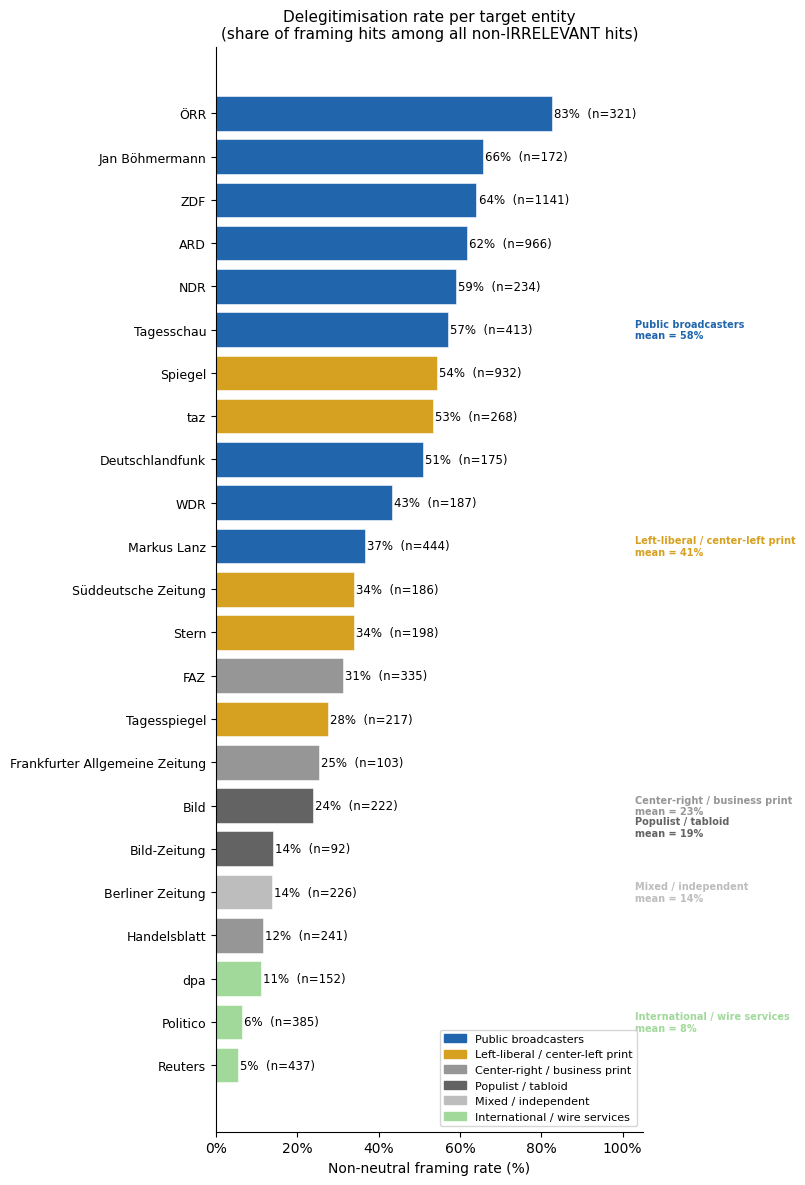

In [16]:
# ── Delegitimisation rate per top hit entity, coloured by institutional group ─
# Delegitimisation rate = share of non-NEUTRAL, non-IRRELEVANT frames

HIT_GROUPS = {
    "Public broadcasters": {
        "color": "#2166ac",
        "members": {"ÖRR", "ZDF", "ARD", "NDR", "Tagesschau",
                    "Deutschlandfunk", "WDR", "Deutschlandradio",
                    "Öffentlich-Rechtliche", "ÖffentlichRechtliche",
                    "Öffentlich-rechtliche Medien", "Jan Böhmermann", "Böhmermann", "Markus Lanz", "Lanz"},
    },
    "Left-liberal / center-left print": {
        "color": "#d6a020",
        "members": {"Spiegel", "Der Spiegel", "taz", "Süddeutsche Zeitung", 
                    "Tagesspiegel", "Stern"},
    },
    "Center-right / business print": {
        "color": "#969696",
        "members": {"FAZ", "Frankfurter Allgemeine Zeitung", "Handelsblatt"},
    },
    "Populist / tabloid": {
        "color": "#636363",
        "members": {"Bild", "Bild-Zeitung"},
    },
    "Mixed / independent": {
        "color": "#bdbdbd",
        "members": {"Berliner Zeitung"},
    },
    "International / wire services": {
        "color": "#a1d99b",
        "members": {"Politico", "Reuters", "BBC", "CNN", "AP", "dpa"},
    },
}

# Build lookup: hit_text → group name
hit_to_group = {}
for group, meta in HIT_GROUPS.items():
    for m in meta["members"]:
        hit_to_group[m] = group

TOP_N = 30   # total hits to show

# Work from the already-split df; exclude NEUTRAL and IRRELEVANT
df_hits = df[~df["category"].isin({"NEUTRAL", "IRRELEVANT"})].copy()
df_all  = df[df["category"] != "IRRELEVANT"].copy()   # denominator: neutral + framing

# Delegitimisation rate per hit entity
total_per_hit   = df_all.groupby("hit_text").size()
framing_per_hit = df_hits.groupby("hit_text").size()
deleg_rate = (framing_per_hit / total_per_hit).dropna()

# Keep only entities that appear in at least one group mapping
known_hits = [h for h in deleg_rate.index if h in hit_to_group]

# Top N by total non-irrelevant hit count
top_hits = (
    total_per_hit[known_hits]
    .nlargest(TOP_N)
    .index.tolist()
)

plot_df = (
    deleg_rate[top_hits]
    .rename("rate")
    .reset_index()
    .rename(columns={"hit_text": "entity"})
)
plot_df["group"]  = plot_df["entity"].map(hit_to_group)
plot_df["n"]      = plot_df["entity"].map(total_per_hit).astype(int)
plot_df["color"]  = plot_df["group"].map(lambda g: HIT_GROUPS[g]["color"])
plot_df = plot_df.sort_values("rate", ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_df) * 0.52)))

bars = ax.barh(plot_df["entity"], plot_df["rate"] * 100,
               color=plot_df["color"], edgecolor="white", linewidth=0.4)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    pct = row["rate"] * 100
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%  (n={row['n']})",
            va="center", fontsize=8.5)

ax.set_xlabel("Non-neutral framing rate (%)", fontsize=10)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(
    "Delegitimisation rate per target entity\n"
    "(share of framing hits among all non-IRRELEVANT hits)",
    fontsize=11,
)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

# Group mean lines per group (vertical tick on right side)
for group, meta in HIT_GROUPS.items():
    group_rows = plot_df[plot_df["group"] == group]
    if group_rows.empty:
        continue
    gmean = group_rows["rate"].mean() * 100
    ymin  = group_rows.index.min() - 0.5 if hasattr(group_rows.index, 'min') else 0
    # Annotate group name and mean to the right
    y_positions = [plot_df.index.get_loc(i) for i in group_rows.index]
    if y_positions:
        ymid = (min(y_positions) + max(y_positions)) / 2
        ax.annotate(
            f"{group}\nmean = {gmean:.0f}%",
            xy=(103, ymid),
            xycoords=("data", "data"),
            fontsize=7, color=meta["color"], fontweight="bold",
            ha="left", va="center", annotation_clip=False,
        )

legend_handles = [
    Patch(color=meta["color"], label=group)
    for group, meta in HIT_GROUPS.items()
    if group in plot_df["group"].values
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, frameon=True)

plt.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()


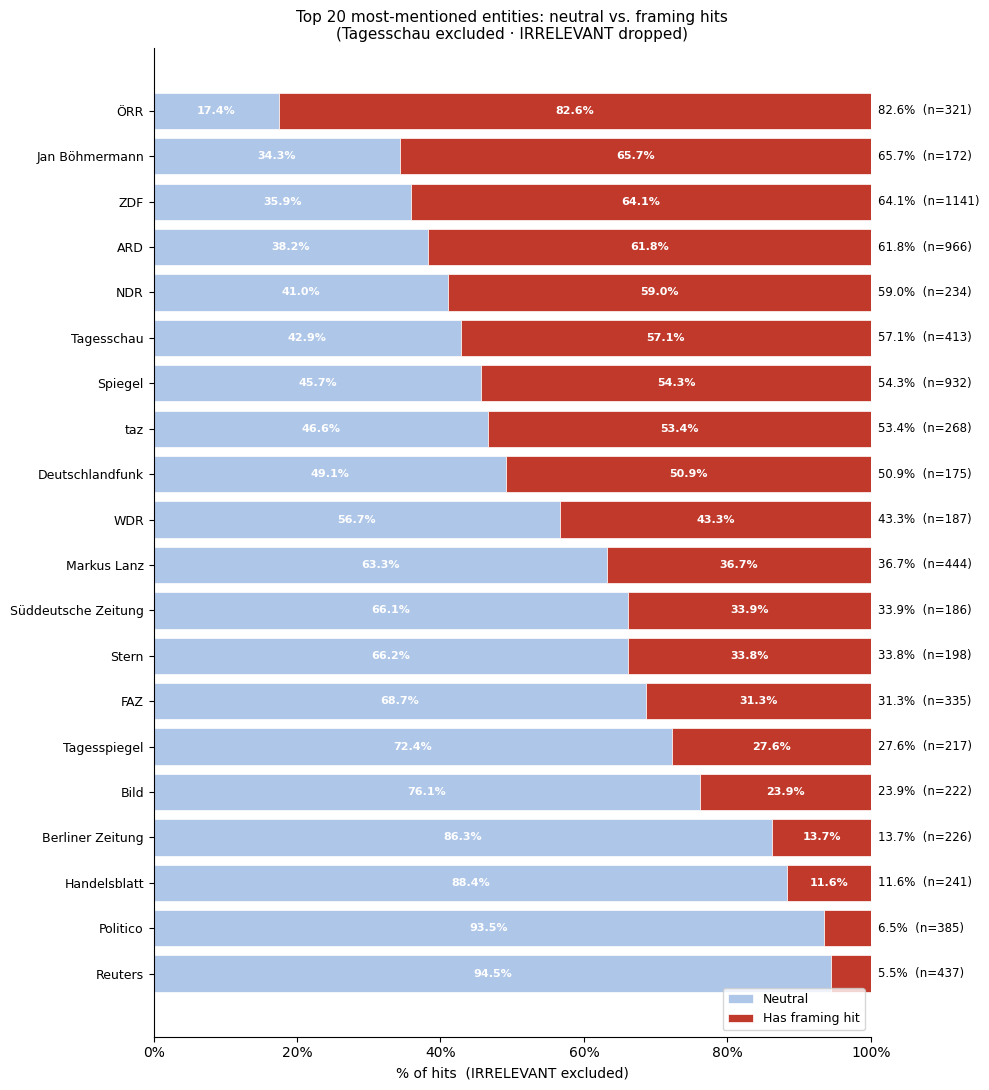

In [17]:
# ── Top 20 most-mentioned entities: neutral vs. framing hits (100% stacked) ──
# Tagesschau excluded as SOURCE; IRRELEVANT dropped; entities sorted by framing rate

TOP_N = 20

# Exclude Tagesschau as source, drop IRRELEVANT
df_hits = df[
    (df["source"] != "Tagesschau") &
    (df["category"] != "IRRELEVANT")
].copy()

df_hits["label"] = df_hits["category"].apply(
    lambda c: "Neutral" if c == "NEUTRAL" else "Has framing hit"
)

# Total hits per entity → top N
top_entities = (
    df_hits.groupby("hit_text").size()
    .nlargest(TOP_N)
    .index.tolist()
)

df_top = df_hits[df_hits["hit_text"].isin(top_entities)]

pivot = (
    df_top.groupby(["hit_text", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Neutral", "Has framing hit"], fill_value=0)
)

totals = pivot.sum(axis=1)
pct    = pivot.div(totals, axis=0) * 100

# Sort by framing rate descending (highest at top of horizontal chart → ascending for barh)
pct    = pct.loc[pct["Has framing hit"].sort_values(ascending=True).index]
totals = totals.reindex(pct.index)

COLORS_NF = {"Neutral": "#aec6e8", "Has framing hit": "#c0392b"}

fig, ax = plt.subplots(figsize=(10, max(6, len(pct) * 0.55)))

lefts = np.zeros(len(pct))
for col in ["Neutral", "Has framing hit"]:
    vals = pct[col].values
    ax.barh(pct.index, vals, left=lefts,
            color=COLORS_NF[col], label=col,
            edgecolor="white", linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 7:
            ax.text(l + v / 2, i, f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    lefts += vals

# Framing % + n= annotation at bar end
for i, (entity, n) in enumerate(totals.items()):
    fp = pct.loc[entity, "Has framing hit"]
    ax.text(101, i, f"{fp:.1f}%  (n={int(n)})", va="center", fontsize=8.5)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("% of hits  (IRRELEVANT excluded)", fontsize=10)
ax.set_title(
    f"Top {TOP_N} most-mentioned entities: neutral vs. framing hits\n"
    "(Tagesschau excluded · IRRELEVANT dropped)",
    fontsize=11,
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()
